In [2]:
import numpy as np
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
import kagglehub

Loading model...


config.json:   0%|          | 0.00/895 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/517M [00:00<?, ?B/s]

The fast path is not available because one of `(selective_state_update, selective_scan_fn, causal_conv1d_fn, causal_conv1d_update, mamba_inner_fn)` is None. Falling back to the sequential implementation of Mamba, as use_mambapy is set to False. To install follow https://github.com/state-spaces/mamba/#installation for mamba-ssm and install the kernels library using `pip install kernels` or https://github.com/Dao-AILab/causal-conv1d for causal-conv1d. For the mamba.py backend, follow https://github.com/alxndrTL/mamba.py.


Loading weights:   0%|          | 0/242 [00:00<?, ?it/s]

MambaForCausalLM LOAD REPORT from: state-spaces/mamba-130m-hf
Key            | Status  | 
---------------+---------+-
lm_head.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]


ACTION 1: Running Statistical Validation (G=4, T=30, 10 Seeds)
Seed 42 | Contaminated Sim: 0.4491 | Isolated Sim: 0.5091 | Diff: 0.0601
Seed 43 | Contaminated Sim: 0.4206 | Isolated Sim: 0.4861 | Diff: 0.0655
Seed 44 | Contaminated Sim: 0.4381 | Isolated Sim: 0.4710 | Diff: 0.0329
Seed 45 | Contaminated Sim: 0.4318 | Isolated Sim: 0.4966 | Diff: 0.0648
Seed 46 | Contaminated Sim: 0.4081 | Isolated Sim: 0.5308 | Diff: 0.1227
Seed 47 | Contaminated Sim: 0.4348 | Isolated Sim: 0.4899 | Diff: 0.0551
Seed 48 | Contaminated Sim: 0.4208 | Isolated Sim: 0.5098 | Diff: 0.0889
Seed 49 | Contaminated Sim: 0.4367 | Isolated Sim: 0.4714 | Diff: 0.0347
Seed 50 | Contaminated Sim: 0.4521 | Isolated Sim: 0.4586 | Diff: 0.0065
Seed 51 | Contaminated Sim: 0.3851 | Isolated Sim: 0.4886 | Diff: 0.1034

--- ACTION 1 RESULTS ---
Mean Similarity Difference: 0.063457
Standard Deviation: 0.032938
If the mean is significantly higher than 0, contamination is statistically real.

ACTION 2: Plotting Regime Depend

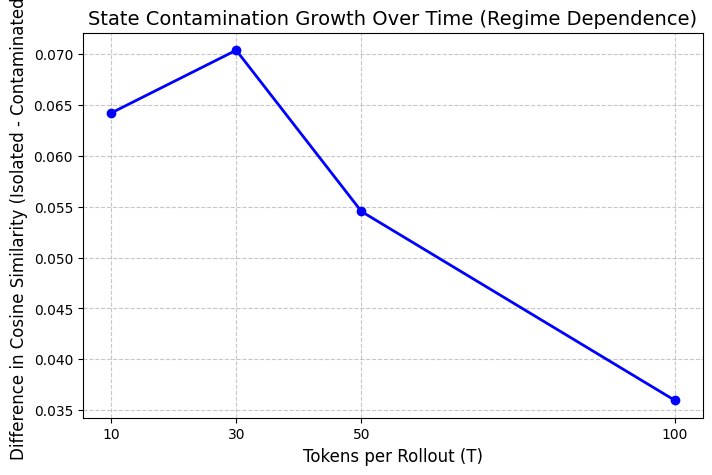

In [4]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, MambaForCausalLM, MambaCache

# ── MODEL SETUP ────────────────────────────────────────────────────────
print("Loading model...")
model_name = "state-spaces/mamba-130m-hf"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = MambaForCausalLM.from_pretrained(model_name, torch_dtype=torch.float32)
model.eval()
prompt = "Solve: John has 5 apples. He gives 2 to Mary. How many does he have?"
inputs = tokenizer(prompt, return_tensors="pt")
prompt_len = inputs.input_ids.shape[1]

# ── UTILITIES ──────────────────────────────────────────────────────────
def snapshot_ssm_states(cache: MambaCache):
    return [s.detach().clone() for s in cache.ssm_states]

def mean_cosine_similarity(states_a, states_b):
    sims = []
    for sa, sb in zip(states_a, states_b):
        sim = F.cosine_similarity(sa.reshape(1, -1), sb.reshape(1, -1)).item()
        sims.append(sim)
    return sum(sims) / len(sims)

# ── THE CORE "BOX" (RUNS 1 EXPERIMENT) ─────────────────────────────────
def run_probe(seed, G, T):
    """
    Sets a random seed, runs the prompt to get a clean state, 
    then runs both Contaminated and Isolated conditions.
    Returns the final cosine similarity of both conditions vs the clean state.
    """
    torch.manual_seed(seed)
    
    # 1. Get Clean h_0
    with torch.no_grad():
        outputs = model(input_ids=inputs.input_ids, use_cache=True)
    h0_clean = snapshot_ssm_states(outputs.cache_params)
    
    # 2. Contaminated Condition (Bleeds across rollouts)
    cache_contaminated = MambaCache(model.config, max_batch_size=1, dtype=torch.float32)
    for layer_idx, s in enumerate(h0_clean):
        cache_contaminated.ssm_states[layer_idx].copy_(s)
        
    with torch.no_grad():
        for k in range(G):
            generated = inputs.input_ids.clone()
            pos = prompt_len
            for t in range(T):
                out = model(
                    input_ids=generated[:, -1:], 
                    cache_params=cache_contaminated, 
                    cache_position=torch.tensor([pos - 1])
                )
                next_token = torch.multinomial(torch.softmax(out.logits[:, -1, :] / 1.0, dim=-1), 1)
                generated = torch.cat([generated, next_token], dim=1)
                pos += 1
            contam_end_state = snapshot_ssm_states(cache_contaminated)
            
    # 3. Isolated Condition (Resets every rollout)
    with torch.no_grad():
        for k in range(G):
            cache_isolated = MambaCache(model.config, max_batch_size=1, dtype=torch.float32)
            for layer_idx, s in enumerate(h0_clean):
                cache_isolated.ssm_states[layer_idx].copy_(s)
                
            generated = inputs.input_ids.clone()
            pos = prompt_len
            for t in range(T):
                out = model(
                    input_ids=generated[:, -1:], 
                    cache_params=cache_isolated, 
                    cache_position=torch.tensor([pos - 1])
                )
                next_token = torch.multinomial(torch.softmax(out.logits[:, -1, :] / 1.0, dim=-1), 1)
                generated = torch.cat([generated, next_token], dim=1)
                pos += 1
            isolated_end_state = snapshot_ssm_states(cache_isolated)

    # Calculate how far both drifted from the clean start by the VERY END of all rollouts
    sim_contam = mean_cosine_similarity(h0_clean, contam_end_state)
    sim_isolated = mean_cosine_similarity(h0_clean, isolated_end_state)
    
    return sim_contam, sim_isolated

# ── ACTION 1: STATISTICAL VALIDATION (10 SEEDS) ────────────────────────
print("\n" + "="*60)
print("ACTION 1: Running Statistical Validation (G=4, T=30, 10 Seeds)")
print("="*60)

G_val = 4
T_val = 30
num_seeds = 10
differences = []

for i in range(num_seeds):
    seed = 42 + i
    sim_c, sim_i = run_probe(seed, G=G_val, T=T_val)
    
    # Difference = How much WORSE the contaminated state is compared to the isolated state
    diff = sim_i - sim_c 
    differences.append(diff)
    print(f"Seed {seed} | Contaminated Sim: {sim_c:.4f} | Isolated Sim: {sim_i:.4f} | Diff: {diff:.4f}")

mean_diff = np.mean(differences)
std_diff = np.std(differences)

print("\n--- ACTION 1 RESULTS ---")
print(f"Mean Similarity Difference: {mean_diff:.6f}")
print(f"Standard Deviation: {std_diff:.6f}")
print("If the mean is significantly higher than 0, contamination is statistically real.")


# ── ACTION 2: REGIME DEPENDENCE PLOT (T=10, 30, 50, 100) ───────────────
print("\n" + "="*60)
print("ACTION 2: Plotting Regime Dependence")
print("="*60)

T_values = [10, 30, 50, 100]
G_plot = 4
mean_diffs_per_T = []

# We use 3 seeds per T to keep it somewhat fast but stable for the plot
seeds_for_plot = [101, 102, 103] 

for t_val in T_values:
    print(f"\nRunning tests for T = {t_val}...")
    temp_diffs = []
    for seed in seeds_for_plot:
        sim_c, sim_i = run_probe(seed, G=G_plot, T=t_val)
        temp_diffs.append(sim_i - sim_c)
    
    avg_diff = np.mean(temp_diffs)
    mean_diffs_per_T.append(avg_diff)
    print(f"Average Difference for T={t_val}: {avg_diff:.4f}")

# Draw the chart
plt.figure(figsize=(8, 5))
plt.plot(T_values, mean_diffs_per_T, marker='o', linestyle='-', color='b', linewidth=2)
plt.title("State Contamination Growth Over Time (Regime Dependence)", fontsize=14)
plt.xlabel("Tokens per Rollout (T)", fontsize=12)
plt.ylabel("Difference in Cosine Similarity (Isolated - Contaminated)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(T_values)

# Save and show the plot
plot_filename = "contamination_regime_plot.png"
plt.savefig(plot_filename, dpi=300)
print(f"\nPlot saved successfully as '{plot_filename}'!")
plt.show()